## Imports et palette

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('../..'))

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from pathlib import Path

plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['font.size']   = 11
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False

# Palette ANS (bleu marine + bleu ciel + rose framboise)
COULEURS = {
    'VALIDE_FORT':    '#1F3864',
    'VALIDE':         '#2E75B6',
    'DOUTEUX':        '#D4A017',
    'REJETE':         '#C00060',
    'SANS_SIREN':     '#A6A6A6',
    'SANS_SIRET':     '#A6A6A6',
    'SIREN_INCONNU':  '#808080',
    'SIRET_INCONNU':  '#808080',
    'SANS_CANDIDAT':  '#404040',
}

# Ordre d'affichage logique (du plus positif au plus indéterminé)
ORDRE_STATUTS_SN = ['VALIDE_FORT', 'VALIDE', 'DOUTEUX', 'REJETE',
                    'SANS_SIREN', 'SIREN_INCONNU', 'SANS_CANDIDAT']
ORDRE_STATUTS_ST = ['VALIDE_FORT', 'VALIDE', 'DOUTEUX', 'REJETE',
                    'SANS_SIRET', 'SIRET_INCONNU', 'SANS_CANDIDAT']

# Hiérarchie pour la déduplication : score = meilleur verdict obtenu
PRIORITE_STATUT = {
    'VALIDE_FORT':   1,
    'VALIDE':        2,
    'DOUTEUX':       3,
    'REJETE':        4,
    'SANS_CANDIDAT': 5,
    'SANS_SIRET':    6,
    'SANS_SIREN':    6,
    'SIRET_INCONNU': 7,
    'SIREN_INCONNU': 7,
}

## Chargement des données (sirenisation + siretisation)

In [2]:
from src.comparaison import (
    charger_sirenisation_depuis_phases,
    charger_siretisation_depuis_phases,
    construire_vue_a,
)
from config.settings import (
    SN_PHASE1, SN_PHASE2, SN_PHASE3,
    ST_PHASE1, ST_PHASE2, ST_PHASE3,
)

df_sn = charger_sirenisation_depuis_phases(SN_PHASE1, SN_PHASE2, SN_PHASE3)
df_st = charger_siretisation_depuis_phases(ST_PHASE1, ST_PHASE2, ST_PHASE3)

print(f'Sirenisation (brut, toutes phases) : {len(df_sn):,} lignes')
print(f'Siretisation (brut, toutes phases) : {len(df_st):,} lignes')

Sirenisation (brut, toutes phases) : 73,034 lignes
Siretisation (brut, toutes phases) : 162,660 lignes


## Déduplication : 1 ligne par entité = verdict final

Pour avoir une synthèse cohérente avec la base d'entités traitées (sans doublons), on garde pour chaque entité **uniquement son meilleur statut atteint à travers les 3 phases**.

Règle : VALIDE_FORT > VALIDE > DOUTEUX > REJETE > SANS_CANDIDAT > SANS_SIRET/SIREN > SIRET/SIREN_INCONNU

In [3]:
def statut_final_par_entite(df, id_col='idstructure_stru'):
    """
    Pour chaque entité (EJ ou EG), garde son verdict final :
      - si validée en P1 → P1
      - sinon si validée en P2 → P2
      - sinon → sa trace en P3 (phase de clôture)
    
    Logique : on parcourt P1 → P2 → P3 ; on retient la première phase où
    l'entité est validée. Si jamais validée, on retient sa trace de la
    dernière phase où elle apparaît (la P3 normalement).
    """
    VALIDES = {'VALIDE_FORT', 'VALIDE'}
    df = df.copy()
    
    # 1) Entités validées en P1
    p1_valides = df[(df['phase'] == 1) & (df['statut'].isin(VALIDES))]
    
    # 2) Entités validées en P2 (et pas déjà validées en P1)
    ids_v1 = set(p1_valides[id_col].astype(str))
    p2_valides = df[
        (df['phase'] == 2) &
        (df['statut'].isin(VALIDES)) &
        (~df[id_col].astype(str).isin(ids_v1))
    ]
    
    # 3) Toutes les autres entités : on prend leur dernière trace
    ids_resolus = ids_v1 | set(p2_valides[id_col].astype(str))
    df_reste = df[~df[id_col].astype(str).isin(ids_resolus)].copy()
    
    # Pour chaque entité non encore résolue, on garde la phase la plus avancée
    df_reste = df_reste.sort_values('phase', ascending=False) \
                       .drop_duplicates(id_col, keep='first')
    
    # Concaténation : on a 1 ligne par entité avec son verdict final
    return pd.concat([p1_valides, p2_valides, df_reste], ignore_index=True)

# Synthèses finales (1 ligne par entité)
df_sn_synth = statut_final_par_entite(df_sn)
df_st_synth = statut_final_par_entite(df_st)

print(f'Sirenisation : {len(df_sn_synth):,} EJ uniques (verdict final)')
print(df_sn_synth['statut'].value_counts().to_string())
print()
print(f'Siretisation : {len(df_st_synth):,} EG uniques (verdict final)')
print(df_st_synth['statut'].value_counts().to_string())

Sirenisation : 54,097 EJ uniques (verdict final)
statut
VALIDE         28234
VALIDE_FORT    23719
DOUTEUX         2098
REJETE            46

Siretisation : 104,612 EG uniques (verdict final)
statut
VALIDE         67191
VALIDE_FORT    26370
DOUTEUX        10070
REJETE           981


## Fonction utilitaire : camembert élégant sans chevauchement

In [4]:
def camembert_elegant(compteurs, palette, titre, fichier, libelle_unite='entités'):
    """
    Camembert classique avec :
      - pourcentage écrit sur la tranche (si >= 3 %)
      - légende externe (statut · count · %)
      - aucun chevauchement
    """
    total = compteurs.sum()
    couleurs = [palette.get(s, '#666666') for s in compteurs.index]
    
    fig, ax = plt.subplots(figsize=(11, 7), subplot_kw=dict(aspect='equal'))
    
    # Ne montrer le % sur la tranche que si elle est >= 3 % (sinon vide)
    def fmt_pct(p):
        return f'{p:.1f} %' if p >= 3 else ''
    
    wedges, texts, autotexts = ax.pie(
        compteurs.values,
        colors=couleurs,
        startangle=90,
        counterclock=False,
        autopct=fmt_pct,
        pctdistance=0.72,
        wedgeprops={'edgecolor': 'white', 'linewidth': 2.5},
        textprops={'fontsize': 11, 'color': 'white', 'fontweight': 'bold'},
    )
    
    # Légende externe avec count + %
    labels_legende = [
        f'{statut}   ·   {n:,}'.replace(',', ' ') + f'   ({n/total*100:.1f} %)'
        for statut, n in zip(compteurs.index, compteurs.values)
    ]
    ax.legend(
        wedges, labels_legende,
        title=f'Total : {total:,} {libelle_unite}'.replace(',', ' '),
        title_fontsize=12,
        loc='center left',
        bbox_to_anchor=(1.05, 0.5),
        frameon=False,
        fontsize=10.5,
        labelspacing=0.9,
    )
    
    ax.set_title(titre, fontsize=15, fontweight='bold', color='#1F3864', pad=20)
    plt.tight_layout()
    plt.savefig(fichier, dpi=150, bbox_inches='tight', facecolor='white')
    plt.show()

## Camembert sirenisation (synthèse finale)

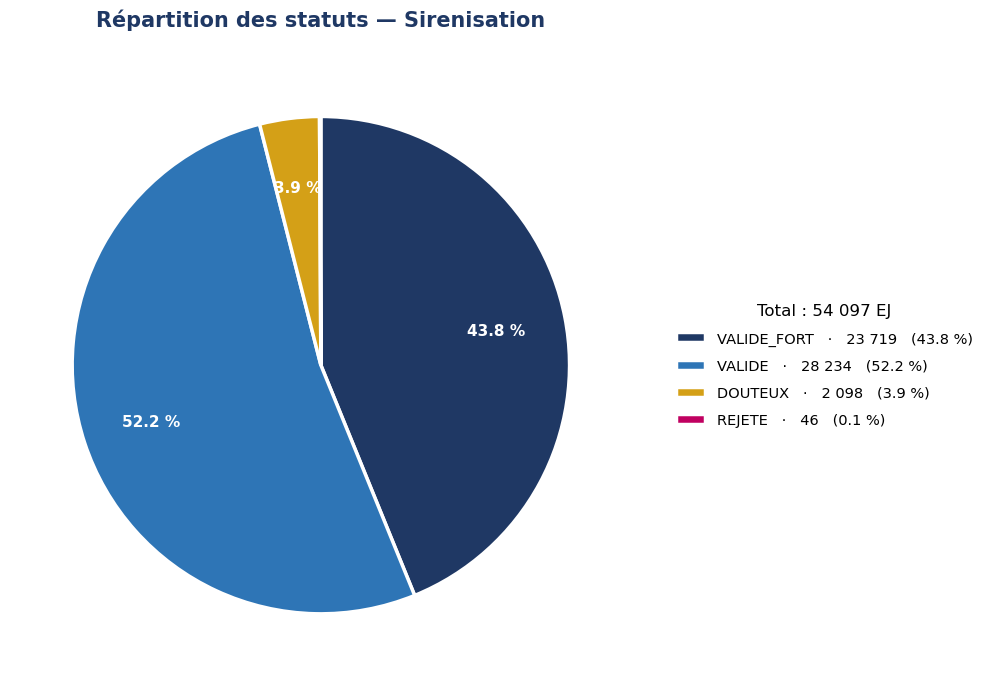

In [5]:
compteurs_sn = df_sn_synth['statut'].value_counts()
compteurs_sn = compteurs_sn.reindex(
    [s for s in ORDRE_STATUTS_SN if s in compteurs_sn.index]
)

camembert_elegant(
    compteurs_sn, COULEURS,
    'Répartition des statuts — Sirenisation',
    'figure_sirenisation_pie.png',
    libelle_unite='EJ',
)

## Camembert siretisation (synthèse finale)

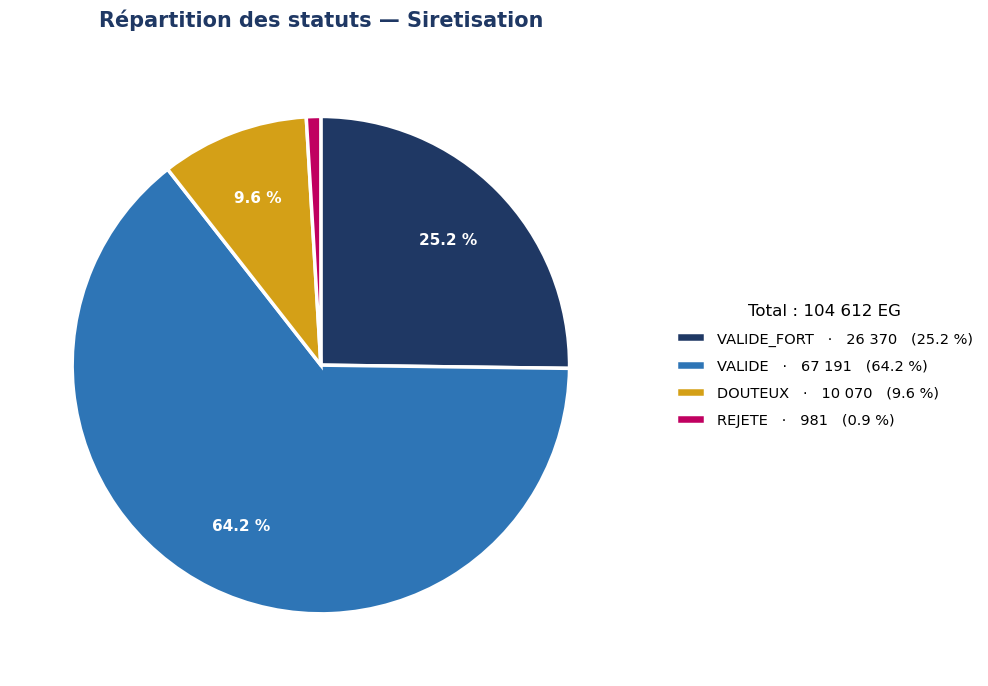

In [6]:
compteurs_st = df_st_synth['statut'].value_counts()
compteurs_st = compteurs_st.reindex(
    [s for s in ORDRE_STATUTS_ST if s in compteurs_st.index]
)

camembert_elegant(
    compteurs_st, COULEURS,
    'Répartition des statuts — Siretisation',
    'figure_siretisation_pie.png',
    libelle_unite='EG',
)

## Histogramme empilé par phase

Détaille pour chaque phase le nombre d'entités par statut **dans la synthèse finale** (pas les candidats intermédiaires).

In [7]:
def histo_empile_par_phase(df_synth, ordre_statuts, palette, titre, fichier):
    phases = [1, 2, 3]
    table = pd.crosstab(df_synth['phase'], df_synth['statut']).reindex(phases, fill_value=0)
    statuts_presents = [s for s in ordre_statuts if s in table.columns]
    table = table[statuts_presents]
    
    fig, ax = plt.subplots(figsize=(11, 6.5))
    
    bas = np.zeros(len(phases))
    for statut in statuts_presents:
        valeurs = table[statut].values
        couleur = palette.get(statut, '#666666')
        ax.bar(phases, valeurs, bottom=bas, label=statut,
               color=couleur, edgecolor='white', linewidth=1.5, width=0.55)
        
        for i, (v, b) in enumerate(zip(valeurs, bas)):
            total_phase = table.iloc[i].sum()
            if total_phase > 0 and v > total_phase * 0.03:
                ax.text(phases[i], b + v/2, f'{v:,}'.replace(',', ' '),
                        ha='center', va='center', fontsize=9.5,
                        color='white', fontweight='bold')
        bas += valeurs
    
    for i, p in enumerate(phases):
        total = table.iloc[i].sum()
        if total > 0:
            ax.text(p, total + total * 0.02, f'{total:,}'.replace(',', ' '),
                    ha='center', va='bottom', fontsize=11, fontweight='bold',
                    color='#1F3864')
    
    ax.set_xticks(phases)
    ax.set_xticklabels([f'Phase {p}' for p in phases], fontsize=12)
    ax.set_ylabel("Nombre d'entités", fontsize=11)
    ax.set_title(titre, fontsize=15, fontweight='bold', color='#1F3864', pad=20)
    ax.grid(axis='y', linestyle='--', alpha=0.3, zorder=0)
    ax.set_axisbelow(True)
    
    total_max = table.sum(axis=1).max()
    if total_max > 0:
        ax.set_ylim(0, total_max * 1.12)
    
    ax.legend(
        title='Statuts', title_fontsize=12,
        loc='center left', bbox_to_anchor=(1.02, 0.5),
        frameon=False, fontsize=10.5, labelspacing=0.7,
    )
    plt.tight_layout()
    plt.savefig(fichier, dpi=150, bbox_inches='tight', facecolor='white')
    plt.show()

## Histogramme empilé par phase — sirenisation

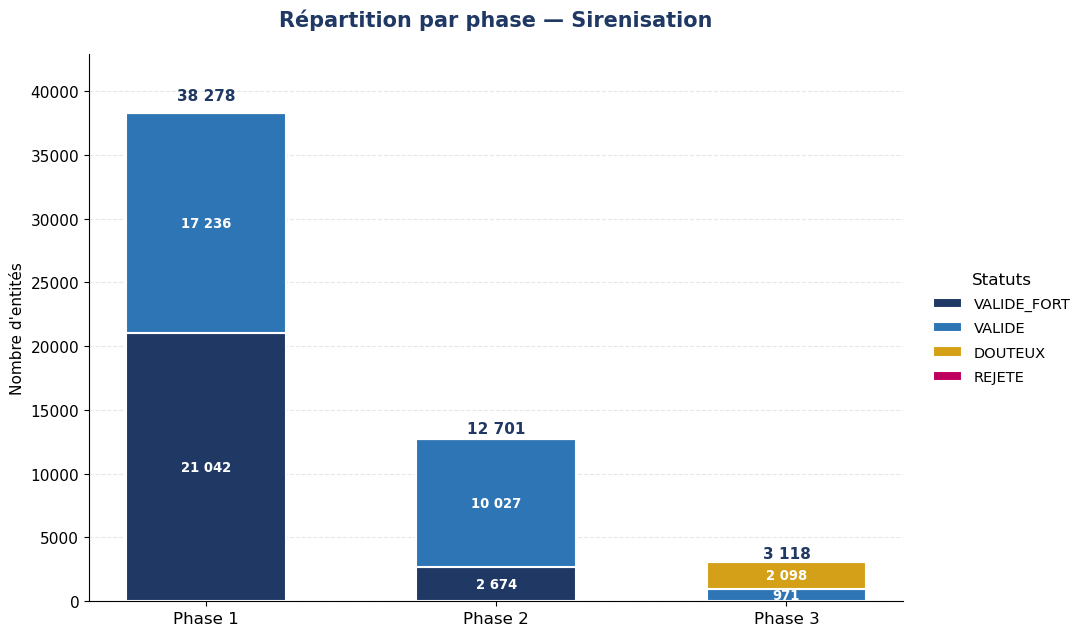

In [8]:
histo_empile_par_phase(
    df_sn_synth, ORDRE_STATUTS_SN, COULEURS,
    'Répartition par phase — Sirenisation',
    'figure_sn_par_phase.png',
)

## Histogramme empilé par phase — siretisation

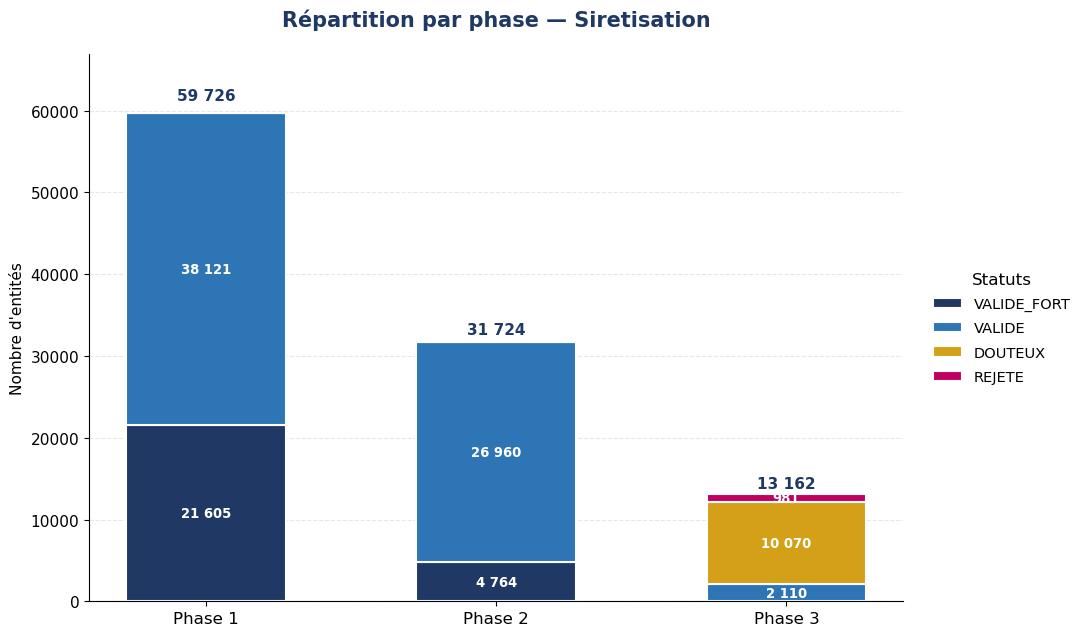

In [9]:
histo_empile_par_phase(
    df_st_synth, ORDRE_STATUTS_ST, COULEURS,
    'Répartition par phase — Siretisation',
    'figure_st_par_phase.png',
)

## Construction de la vue A (cohérence SIREN ↔ SIRET)

In [10]:
df_vue_a = construire_vue_a(df_st, df_sn)
print(f'Lignes vue A : {len(df_vue_a):,}')
print()
print(df_vue_a['statut_coherence'].value_counts().to_string())

Lignes vue A : 99,281

statut_coherence
COHERENT      78198
INCOHERENT    13947
PARTIEL_EJ     5720
PARTIEL_EG     1416


## Synthèse de la cohérence au niveau EJ

Pour chaque EJ traité, on détermine sa situation finale :
- **EJ tous EG cohérents** : EJ validé + tous ses EG validés avec SIREN cohérent
- **EJ avec au moins un EG incohérent** : EJ validé mais ≥ 1 EG a un SIRET[:9] ≠ SIREN_EJ
- **EJ seul validé** : EJ validé, aucun EG validé associé
- **EG seuls validés (sans EJ valide)** : situations côté EG sans EJ parent validé

In [11]:
# Grouper les EG validés par leur EJ parent (référence côté EG)
df_avec_match = df_vue_a[df_vue_a['statut_coherence'].isin(['COHERENT', 'INCOHERENT'])]
par_ej = df_avec_match.groupby('nmfinessej_eg')['statut_coherence'].apply(set)

nb_ej_tous_coh    = sum(1 for s in par_ej if s == {'COHERENT'})
nb_ej_avec_incoh  = sum(1 for s in par_ej if 'INCOHERENT' in s)
nb_partiel_ej     = int((df_vue_a['statut_coherence'] == 'PARTIEL_EJ').sum())
nb_partiel_eg     = int((df_vue_a['statut_coherence'] == 'PARTIEL_EG').sum())
nb_orphelins      = int((df_vue_a['statut_coherence'] == 'ORPHELIN').sum())

print('Synthèse au niveau EJ :')
print(f'  EJ avec tous EG cohérents       : {nb_ej_tous_coh:,}'.replace(',', ' '))
print(f'  EJ avec au moins un incohérent  : {nb_ej_avec_incoh:,}'.replace(',', ' '))
print(f'  EJ validés sans EG validé       : {nb_partiel_ej:,}'.replace(',', ' '))
print(f'  EG validés sans EJ valide       : {(nb_partiel_eg + nb_orphelins):,}'.replace(',', ' '))

Synthèse au niveau EJ :
  EJ avec tous EG cohérents       : 40 137
  EJ avec au moins un incohérent  : 6 096
  EJ validés sans EG validé       : 5 720
  EG validés sans EJ valide       : 1 416


## Camembert de la cohérence (synthèse au niveau EJ)

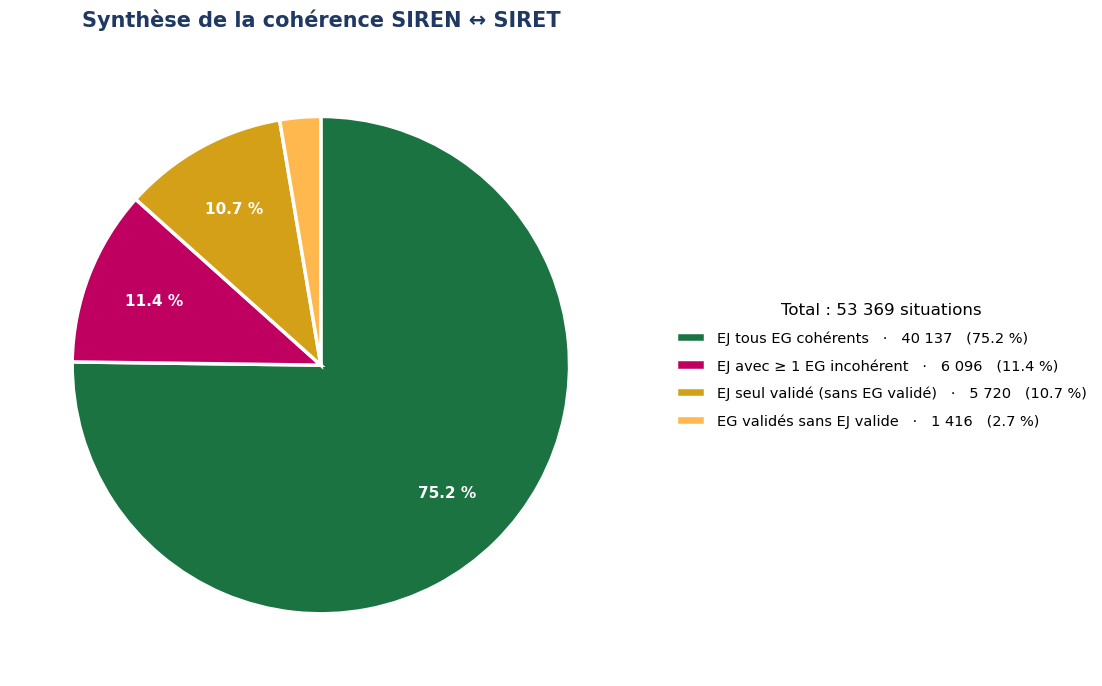

In [12]:
# Compteurs basés sur la synthèse EJ (pas sur les couples bruts)
synth_coh = pd.Series({
    'EJ tous EG cohérents':            nb_ej_tous_coh,
    'EJ avec ≥ 1 EG incohérent':       nb_ej_avec_incoh,
    'EJ seul validé (sans EG validé)': nb_partiel_ej,
    'EG validés sans EJ valide':       nb_partiel_eg + nb_orphelins,
})

# Couleurs : vert pour cohérent, framboise pour incohérent, orangé pour partiels
COULEURS_COHERENCE = {
    'EJ tous EG cohérents':            '#1A7341',
    'EJ avec ≥ 1 EG incohérent':       '#C00060',
    'EJ seul validé (sans EG validé)': '#D4A017',
    'EG validés sans EJ valide':       '#FFB84D',
}

camembert_elegant(
    synth_coh, COULEURS_COHERENCE,
    'Synthèse de la cohérence SIREN ↔ SIRET',
    'figure_coherence_pie.png',
    libelle_unite='situations',
)